# Seaborn Categorical plots

Plots where one axis is a category, not a number. Seven main functions split into three groups:

- **Distribution per category**: `boxplot`, `violinplot`, `boxenplot`
- **Individual observations per category**: `stripplot`, `swarmplot`
- **Summary statistic per category**: `barplot`, `pointplot`, `countplot`

Plus `catplot` as the figure-level wrapper for all of them.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(0)

penguins = sns.load_dataset("penguins")
tips = sns.load_dataset("tips")
titanic = sns.load_dataset("titanic")

## boxplot

A **box plot** shows median, quartiles, and outliers for each group.

- The box spans the 25th to 75th percentile (the IQR).
- The line inside the box is the median.
- The whiskers extend to 1.5 × IQR from the box.
- Points beyond the whiskers are plotted individually as outliers.


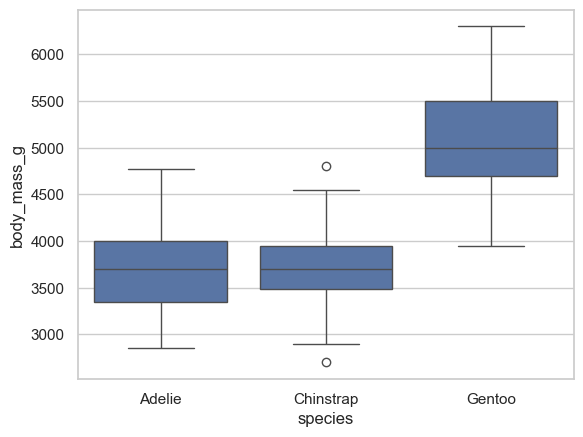

In [2]:
sns.boxplot(data=penguins, x="species", y="body_mass_g")
plt.show()

### Adding hue for a second category

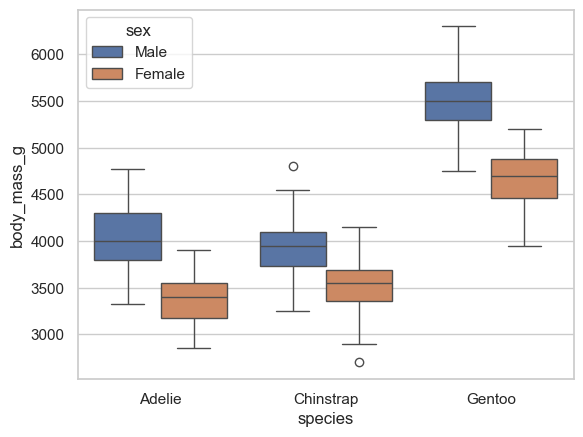

In [3]:
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="sex")
plt.show()

Each species now has two boxes side by side (one per sex). Easy to
see that males are heavier than females across all three species.

Pros of boxplots: compact, robust to outliers, focus on quartiles.
Cons: hide the actual shape — a bimodal distribution and a uniform one
can look identical in a box plot.


## violinplot — KDE per category

A **violin plot** is like a box plot, but each "box" is replaced with a
mirrored KDE showing the actual distribution shape.


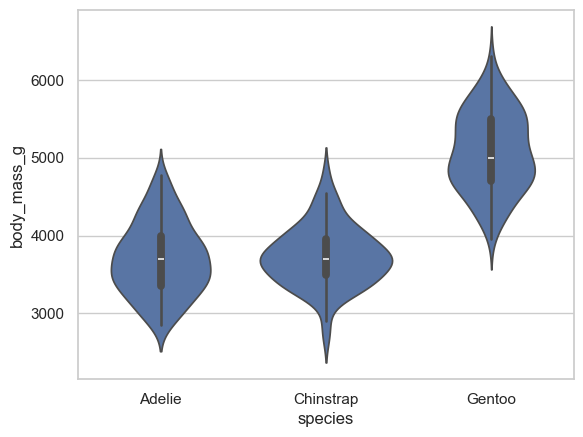

In [4]:
sns.violinplot(data=penguins, x="species", y="body_mass_g")
plt.show()

Inside each violin you can also see the box plot. To remove it:


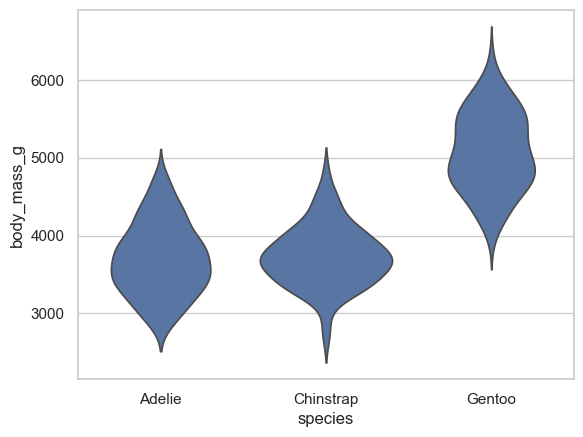

In [5]:
sns.violinplot(data=penguins, x="species", y="body_mass_g", inner=None)
plt.show()

`inner=` options: `"box"` (default), `"quart"` (quartile lines),
`"point"` (each observation), `"stick"` (small ticks per observation),
`None`.


### split=True for two-group comparison

When `hue` has exactly two levels, `split=True` puts the two halves of
the violin on the same axis. Useful for direct comparison.


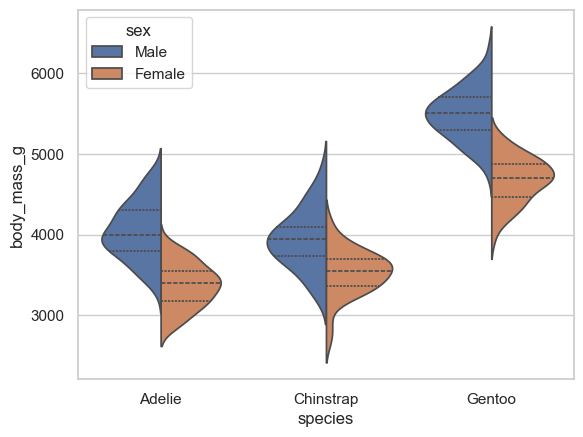

In [6]:
sns.violinplot(data=penguins, x="species", y="body_mass_g",
               hue="sex", split=True, inner="quart")
plt.show()

## boxenplot — for larger datasets

A **boxen plot** (also called letter-value plot) is like a box plot with
more boxes showing more quantiles. Useful for medium-to-large datasets
where you want to see tail behavior.


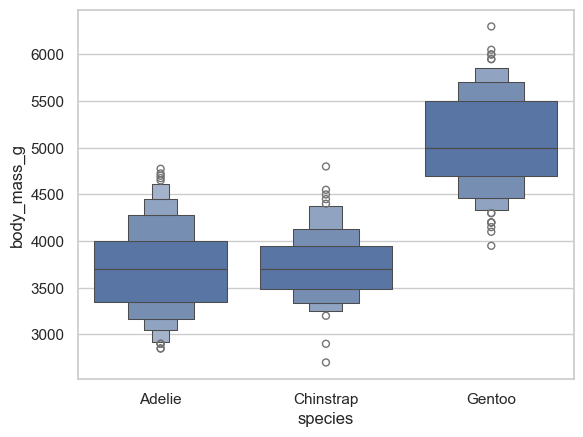

In [7]:
sns.boxenplot(data=penguins, x="species", y="body_mass_g")
plt.show()

For penguins (n ≈ 344) the difference vs a box plot is subtle.
Boxenplot really shines at n > 1000 where outlier-detection rules in
boxplots break down.


## stripplot — every point, one per row

A **strip plot** shows every observation as a separate point. Good for
small datasets.


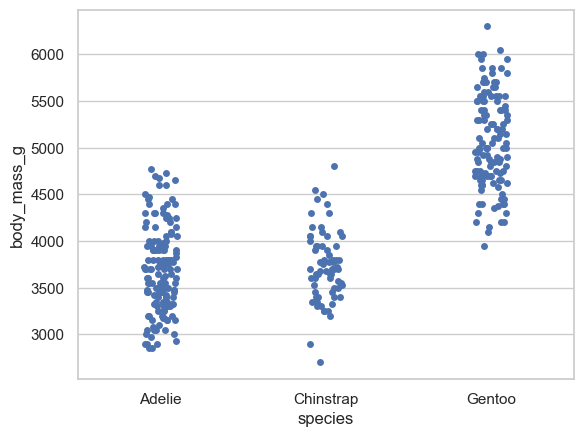

In [8]:
sns.stripplot(data=penguins, x="species", y="body_mass_g")
plt.show()

Points are jittered horizontally to reduce overlap. Without
jittering they would stack on top of each other and you would see only
one column per species.


## swarmplot — no overlap, all points visible

A **swarm plot** also shows every observation but adjusts positions so
points never overlap. Better than strip plot for small-to-medium data.


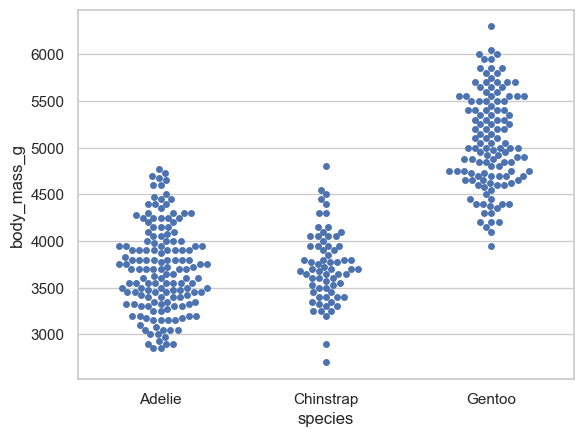

In [9]:
sns.swarmplot(data=penguins, x="species", y="body_mass_g")
plt.show()

Limits: swarmplot becomes unreadable past a few hundred points per
category, and seaborn will warn you when this happens. For larger data,
go back to violinplot or boxplot.


### Combining strip/swarm with box/violin

A common pattern: put the box plot for the summary, overlay the swarm
plot for the actual data.


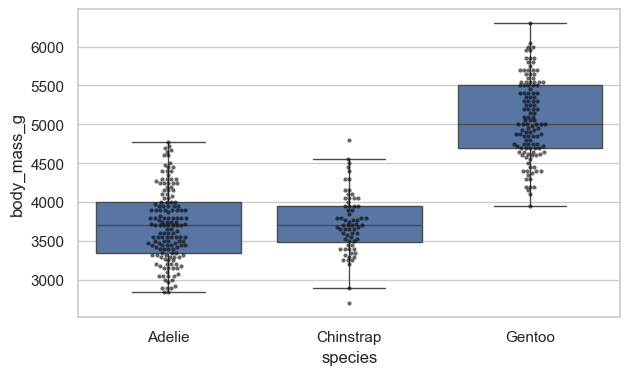

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=penguins, x="species", y="body_mass_g",
            ax=ax, fliersize=0)  # hide default outlier markers
sns.swarmplot(data=penguins, x="species", y="body_mass_g",
              ax=ax, color="black", size=3, alpha=0.6)
plt.show()

## barplot — mean (or other statistic) per category

A **bar plot** shows a single summary statistic per category. By default
the statistic is the mean.


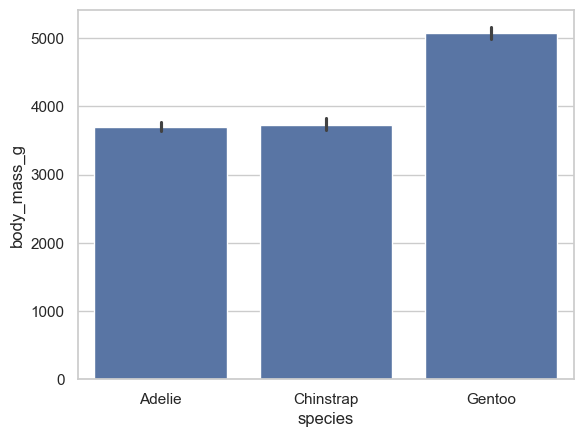

In [11]:
sns.barplot(data=penguins, x="species", y="body_mass_g")
plt.show()

The error bars are 95% confidence intervals around the mean
(seaborn's default). Like `lineplot`, you can change with `errorbar=`.

### A common ML usage — class proportions

To show a different statistic, pass `estimator=`. For example, sum
instead of mean:


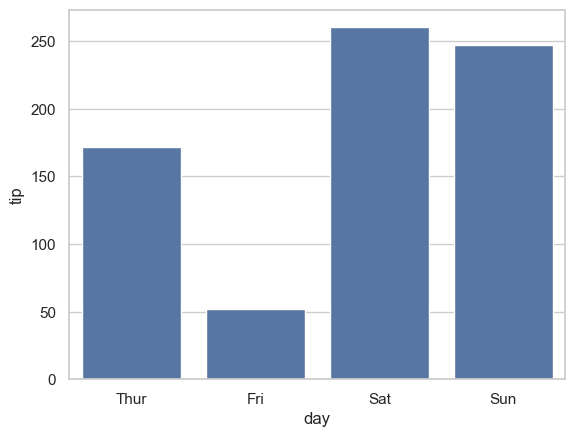

In [12]:
sns.barplot(data=tips, x="day", y="tip", estimator="sum", errorbar=None)
plt.show()

Useful estimators: `"mean"`, `"median"`, `"sum"`, `"min"`, `"max"`,
or any callable.


## countplot — bar plot of counts

A specialized barplot that counts rows per category. Equivalent to
`barplot` with the y-axis being row count.


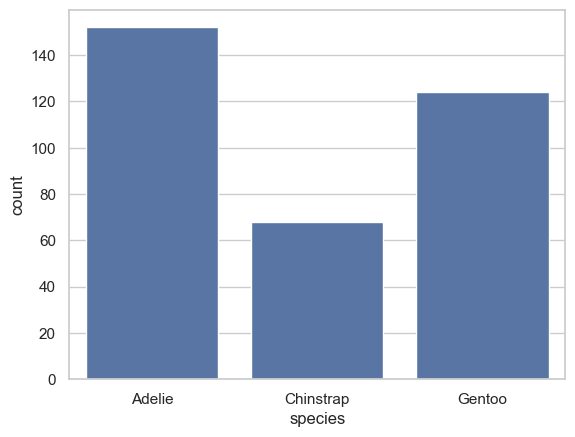

In [13]:
sns.countplot(data=penguins, x="species")
plt.show()

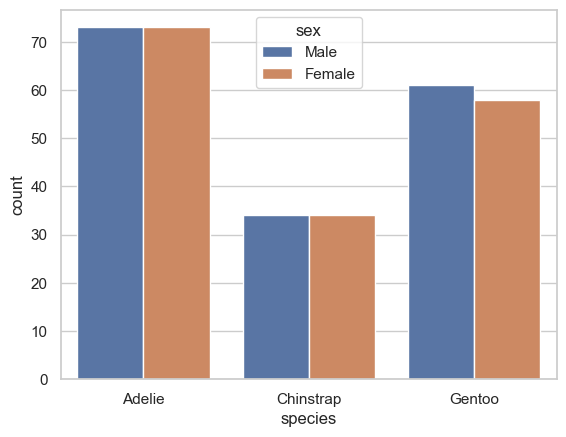

In [14]:
# With hue for breakdown by a second category
sns.countplot(data=penguins, x="species", hue="sex")
plt.show()

For categorical EDA this is the workhorse — fast way to see class
balance in your dataset.


## pointplot — mean as a connected line

Like barplot but uses points and lines instead of bars. Better when
you want to see trends across categories rather than absolute heights.


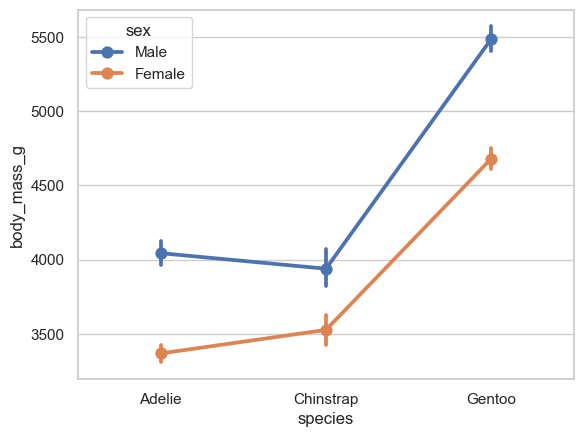

In [15]:
sns.pointplot(data=penguins, x="species", y="body_mass_g", hue="sex")
plt.show()

Lines between points imply ordering. Only use pointplot when the
x-axis categories have a natural order (e.g., ordinal data, time
periods), or for `hue` comparisons across an unordered x.


## catplot — figure-level for all of the above

`catplot` is the figure-level wrapper. Switch plot type with `kind=`.


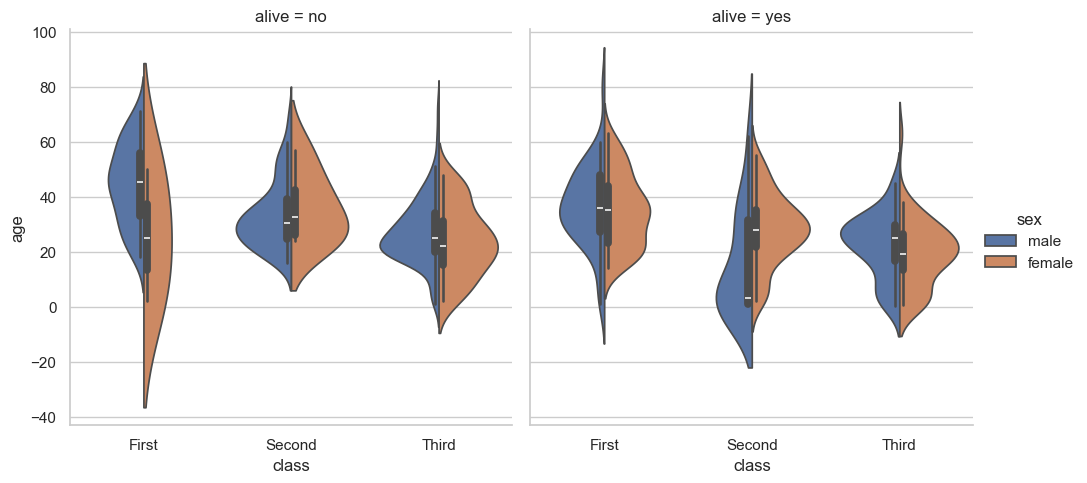

In [16]:
sns.catplot(
    data=titanic,
    x="class",
    y="age",
    hue="sex",
    col="alive",
    kind="violin",
    split=True,
)
plt.show()

Same plotting logic, faceted by survival outcome. Great for
comparing distributions across multiple categorical splits.

`kind=` values: `"strip"` (default), `"swarm"`, `"box"`, `"violin"`,
`"boxen"`, `"point"`, `"bar"`, `"count"`.


## Choosing the right categorical plot


| What you want to show | Use |
|---|---|
| Group means (small data, < 1000 per group) | swarmplot + barplot overlay |
| Group distributions (general purpose) | boxplot |
| Group distributions with shape detail | violinplot |
| Group distributions with heavy tails or large n | boxenplot |
| Counts per category | countplot |
| Means with error bars | barplot |
| Trends across ordered categories | pointplot |
| Many small groups, faceted | catplot with col/row |


**1. boxplot hides distribution shape.** Two very different distributions
can look identical. Prefer violin or strip/swarm overlay if shape matters.

**2. barplot defaults to mean, not sum.** Common surprise when you expect
"total revenue per day" and get the average. Use `estimator="sum"`.

**3. countplot only takes x OR y, not both.** It's just counting rows
per category — if you want a 2D count, use `histplot` with two
categorical axes.

**4. pointplot's connecting lines are misleading for unordered x.**
A line between "monday" and "tuesday" suggests progression. A line
between "apple" and "banana" suggests nothing. Use barplot if x is
unordered.

**5. order matters.** Set explicit `order=[...]` and `hue_order=[...]`
when you want consistent layout across multiple plots.

**6. swarmplot is slow on large data.** Past ~1000 points per group,
prefer strip with high jitter, or switch to violinplot.
